# Tutorial 2 - Fish Habitat Assessment using the MesoHABSIM Model 

This tutorial demonstrates how to use the `SARAwater` package to assess fish habitat using the MesoHABSIM model.

## Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sarawater as sara

## Import the flow time series

This tutorial needs a CSV file with the flow discharge time series for the reach, with at least two columns: "Date" (the timestamps) and "Q" (the flow discharge, in cubic meters per second, m³/s).

You have two options to provide this file:

1. **Use your own data**: place your CSV file in the `data` folder next to this notebook, and update the filename in the cell below.

2. **Use the example dataset**: do nothing: if no local file is found, the notebook automatically downloads the example dataset used in this tutorial from the [SARAwater GitHub repository](https://github.com/sara-acqua/sarawater)

In [2]:
input_csv_filepath = os.path.join("data", "daily_discharge_30y.csv")

if os.path.isfile(input_csv_filepath):
    print(f"Using your local file: {input_csv_filepath}")
    reach_df = pd.read_csv(input_csv_filepath, parse_dates=["Date"])
else:
    print("No local file found - downloading the example dataset from GitHub instead.")
    GITHUB_DATA_URL = "https://raw.githubusercontent.com/sara-acqua/sarawater/main/tutorials/tutorial_2_habitat/data/daily_discharge_30y.csv"
    reach_df = pd.read_csv(GITHUB_DATA_URL, parse_dates=["Date"])

reach_df.head()

Using your local file: data\daily_discharge_30y.csv


,Date,Q
0,1989-01-01,0.142379
1,1989-01-02,0.139673
2,1989-01-03,0.136700
3,1989-01-04,0.133566
4,1989-01-05,0.130386


In [3]:
# Convert the timestamps of the csv file to a list of datetime objects
datetime_list = reach_df["Date"].dt.to_pydatetime().tolist()

# Put the discharge data into a numpy array
discharge_data = np.array(reach_df["Q"].values)

# Define the maximum flow discharge that can be abstracted from the river reach (in m3/s)
Qabs_max = 0.2

# Create a Reach object with the imported data
my_reach = sara.Reach("My Reach", datetime_list, discharge_data, Qabs_max)

## Initialize a reach object

## Add scenarios to the reach object

### Minimum release scenario

In [4]:
Qreq_months = [
    0.09,
    0.09,
    0.09,
    0.106,
    0.106,
    0.106,
    0.106,
    0.1,
    0.1,
    0.106,
    0.106,
    0.09,
]

# Create a constant scenario with these values
MFR_scenario = sara.ConstScenario(
    name="MFR",
    description="Minimum Flow Requirement scenario from CSV file",
    reach=my_reach,
    Qreq_months=Qreq_months,
)

# Add the scenario to the reach
my_reach.add_scenario(MFR_scenario)

# Print the min and max MFR values
min_mfr = np.min(MFR_scenario.Qreq_months)
max_mfr = np.max(MFR_scenario.Qreq_months)
print(f"MFR values range from {min_mfr:.3f} to {max_mfr:.3f} [m^3/s]")

MFR values range from 0.090 to 0.106 [m^3/s]


### Ecological scenario (using the built-in method)

In [5]:
my_reach.add_ecological_flow_scenario(
    "EF", "Ecological Flow Scenario with default parameters"
)

Scenario(name=EF, description=Ecological Flow Scenario with default parameters, reach=My Reach)

### Let's check we added the scenarios correctly

In [6]:
my_reach.print_scenarios()

scenarios[0]: MFR | Minimum Flow Requirement scenario from CSV file
scenarios[1]: EF | Ecological Flow Scenario with default parameters


## Compute the released flow discharge and abstracted flow for each scenario

In [7]:
for scenario in my_reach.scenarios:
    scenario.compute_Qrel()
    scenario.compute_natural_abstracted_volumes()

## Habitat analysis

Read Habitat-Discharge curves from input data

In [8]:
HQ_curves_filepath = os.path.join("data", "HQ_curves.txt")

if os.path.isfile(HQ_curves_filepath):
    print(f"Using your local file: {HQ_curves_filepath}")
    HQ_curve_df = pd.read_csv(HQ_curves_filepath, sep="\t", header="infer")
else:
    print("No local file found - downloading the example dataset from GitHub instead.")
    GITHUB_HQ_URL = "https://raw.githubusercontent.com/sara-acqua/sarawater/main/tutorials/tutorial_2_habitat/data/HQ_curves.txt"
    HQ_curve_df = pd.read_csv(GITHUB_HQ_URL, sep="\t", header="infer")

my_reach.add_HQ_curve(HQ_curve_df)

Using your local file: data\HQ_curves.txt


In [9]:
my_reach.get_list_available_HQ_curves()

['BROW_A_R', 'MARB_A_R', 'TROU_J_R']

Compute IH for each species and scenario

In [10]:
for scenario in my_reach.scenarios:
    scenario.compute_IH_for_species()
    for species in scenario.IH.keys():
        print(
            f"Scenario {scenario.name}, Species {species}, IH: {scenario.IH[species].IH}"
        )

Scenario MFR, Species BROW_A_R, IH: 0.15577265510659258
Scenario MFR, Species MARB_A_R, IH: 0.07702982228117508
Scenario MFR, Species TROU_J_R, IH: 0.669112667411991
Scenario EF, Species BROW_A_R, IH: 0.28378208424489687
Scenario EF, Species MARB_A_R, IH: 0.07287254992102295
Scenario EF, Species TROU_J_R, IH: 0.7244099452005035


## Draw Plots

Set `matplotlib`'s plotting parameters.

In [11]:
plt.rcParams.update(
    {
        "figure.figsize": (8, 6),
        "font.size": 17,
        "legend.fontsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "lines.linewidth": 2.5,
        "mathtext.fontset": "cm",
    }
)

Set color array for the scenarios. The first element of this list will be the color of the first scenario added to the Reach, and so on with the following scenarios.

In [12]:
scenario_colors = [
    "tab:red",
    "tab:orange",
    "tab:green",
    "tab:purple",
    "tab:brown",
    "tab:pink",
]

Initialize a `ReachPlotter` object

In [13]:
plotter = sara.ReachPlotter(my_reach, scenario_colors=scenario_colors)

Full HQ curves

<Axes: title={'center': 'Habitat-Discharge (HQ) curves'}, xlabel='Flow discharge $[\\mathrm{m}^3/\\mathrm{s}]$', ylabel='Available habitat area $[\\mathrm{m}^2]$'>

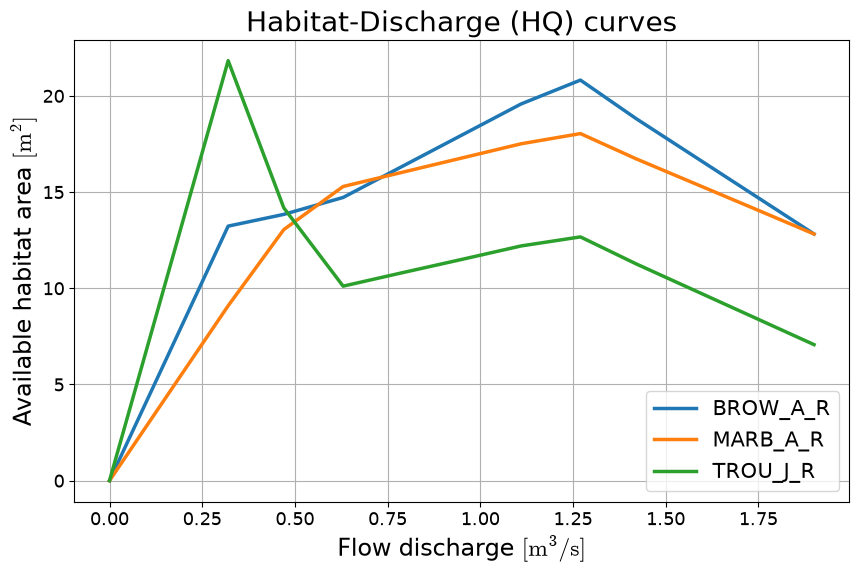

In [14]:
plotter.plot_hq_curves()

HQ curves setting xlim, and showing the DMV (or another constant scenario) range

<Axes: title={'center': 'Habitat-Discharge (HQ) curves'}, xlabel='Flow discharge $[\\mathrm{m}^3/\\mathrm{s}]$', ylabel='Available habitat area $[\\mathrm{m}^2]$'>

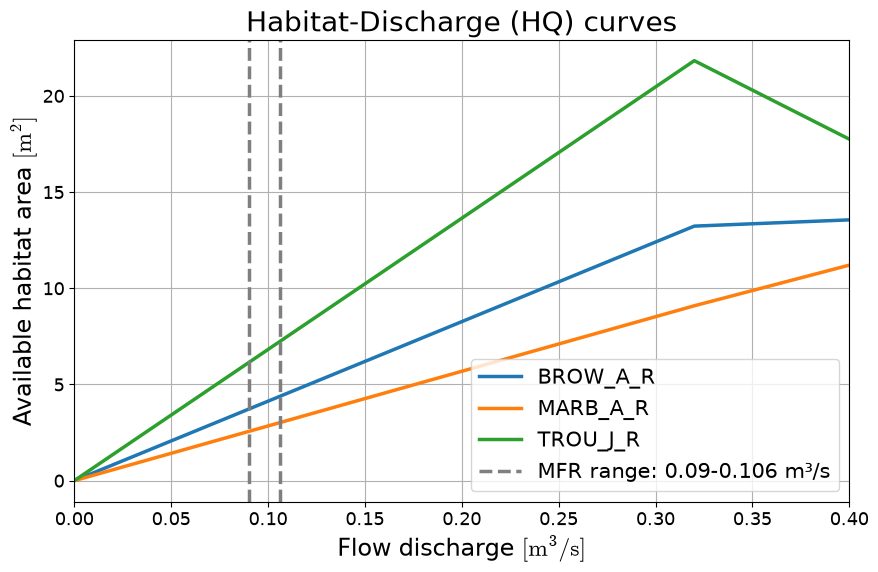

In [15]:
plotter.plot_hq_curves(xlim=0.4, rule_min=min_mfr, rule_max=max_mfr, rule_name="MFR")

Habitat timeseries for a given species in all scenarios

<Axes: title={'center': 'My Reach - Habitat Time Series - BROW_A_R'}, xlabel='Date', ylabel='Available Habitat Area [%]'>

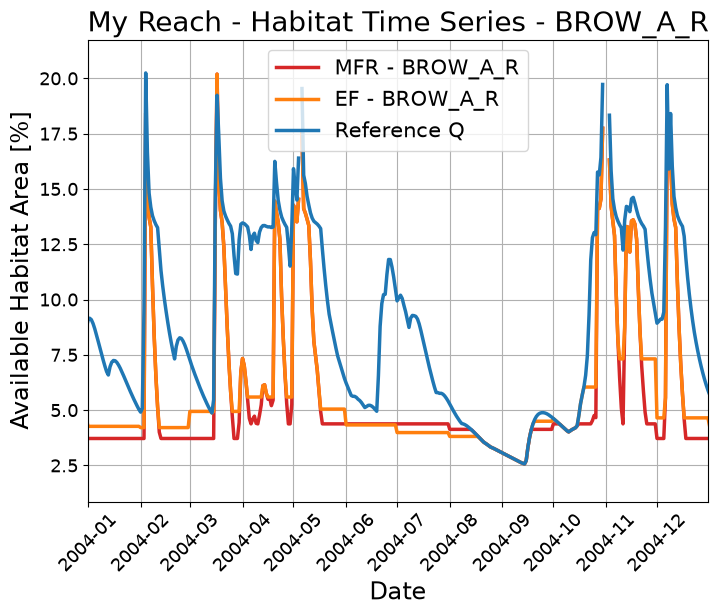

In [16]:
plotter.plot_habitat_timeseries("BROW_A_R", start_year=2004, end_year=2004, save=True)

UCUT

<Axes: title={'center': 'My Reach - UCUT - BROW_A_R'}, xlabel='Cumulative continuous duration [%]', ylabel='Continuous days below threshold [days]'>

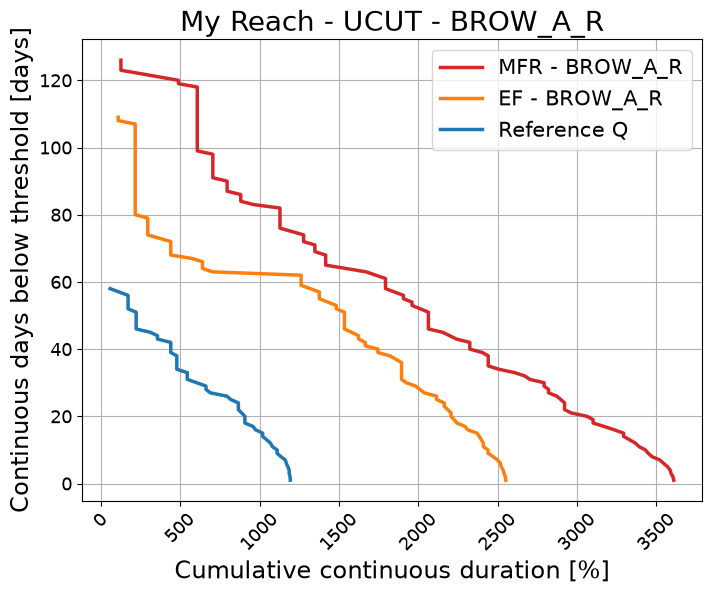

In [17]:
plotter.plot_ucut_curves("BROW_A_R")

IH_vs_volume

<Axes: title={'center': 'My Reach - IH vs Abstracted Volume'}, xlabel='Habitat Index $(IH)$ [-]', ylabel='Normalized abstracted volume $V_{der}/V_{nat}$ [-]'>

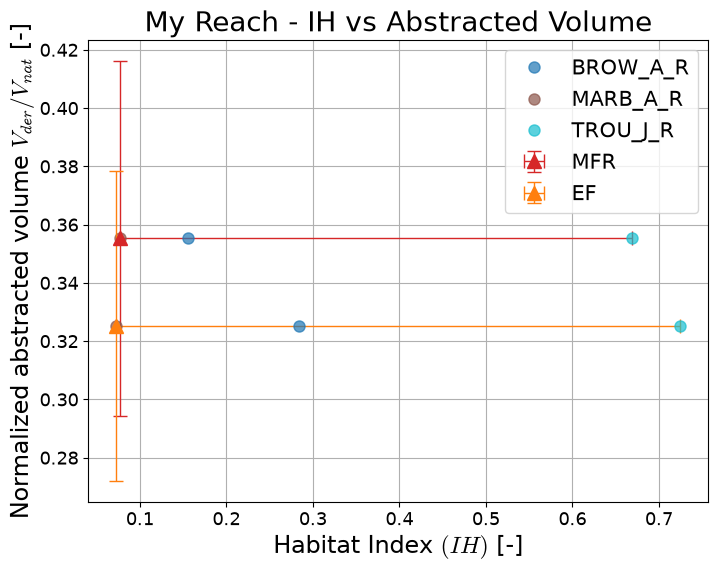

In [18]:
plotter.plot_ih_vs_volume(save=True)